# Gradient Descent

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Gradient descent is a key algorithm in training machine learning models. It works by working with a cost function $J(\beta)$, where the goal is to minimize this cost function. Here $\beta$ are the parameters of the model. By using this cost function and adjusting the parameters iteratively, we can improve the performance of the model. This is also know as fitting in a statistical context.

An example is the MSE cost function in linear regression, where the squared difference between prediction and real value is used to evaluate the difference. This is then used to calculate how much each parameter value has to be adjusted, 'descending' into the direction of the gradient to a minimum. Ideally, cost functions are chosen to be convex, such that there is only global minimum that is easily reachable. This ensures convergence as long as the learning rate has benn chosen appropriately.

In higher dimensions, this may become complicated. We need to calculate $-\nabla J (\hat{\beta})$, which is the gradient that points into the direction of the greatest decrease, towards a minimum. This results in a vector of partial derivatives: $\nabla J (\hat{\beta})=\left[ \frac{\partial J}{\partial\hat{\beta}}\right]$, which we can then use to update the parameter values in the direction of the gradient. This is done by subtracting the gradient from the current point, multiplied by a learning rate.

$$
\omega_{n+1} = \omega_n - \alpha \nabla J (\hat{\beta})
$$

## Generating data from a known distribution

First we need some data.

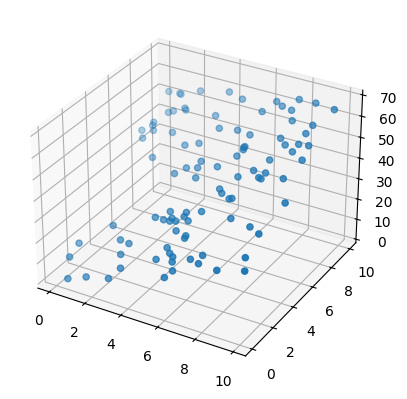

In [15]:
np.random.seed(1234)  ## This ensures we get the same data if all of the other parameters remain fixed

num_obs = 100
x1 = np.random.uniform(0,10,num_obs)
x2 = np.random.uniform(0,10,num_obs)
const = np.ones(num_obs)
eps = np.random.normal(0,.5,num_obs)

b = 1.5
theta_1 = 2
theta_2 = 5

y = b*const+ theta_1*x1 + theta_2*x2 + eps

x_mat = np.array([const,x1,x2]).T

ax = plt.figure().add_subplot(projection='3d')
ax.scatter(x1, x2, y)

We can solve this in two ways, by using a LinearRegression model (since we know the function is linear as we created the data ourselves), or by using matrix algebra directly.

In both cases the values are a little off, which makes sense since a small epsilon value was added for randomization. The results are identical for both methods.

In [5]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression(fit_intercept=False)
lr_model.fit(x_mat, y)

lr_model.coef_

array([1.49004618, 1.99675416, 5.01156315])

The method below uses the least squares method to solve the problem directly. The model we assume is $y = X\theta$, where we set the gradient to 0: 

$\nabla_\theta |X\theta - y |^2 = 2X^T(X\theta - y) = 0$. 

We can rearrange this to: 

$X^T X \theta = X^T y$, 

also known as the *normal equations*. If $X^TX$ is invertible, we recover the expression used below 

$\theta = (X^TX)^{-1}X^T y$

In [6]:
np.linalg.inv(np.dot(x_mat.T,x_mat)).dot(x_mat.T).dot(y)

array([1.49004618, 1.99675416, 5.01156315])

## Solving with Gradient Descent

Most numerical problems can't be solved with an analytical solution, and require an iterative method that converges to a solution. One method of finding such a result is Gradient Descent, which is often used in Neural Networks.

Here we show full-batch gradient descent, which means that all of the data is used to update the parameters.

In [24]:
learning_rate = 3e-3
num_iter = 10000
theta_initial = np.array([3,3,3])

In [25]:
def gradient_descent(learning_rate, num_iter, theta_initial):

    ## Initialization steps
    theta = theta_initial
    theta_path = np.zeros((num_iter+1,3))
    theta_path[0,:]= theta_initial

    loss_vec = np.zeros(num_iter)

    ## Main Gradient Descent loop (for a fixed number of iterations)
    for i in range(num_iter):
        y_pred = np.dot(theta.T,x_mat.T)
        loss_vec[i] = np.sum((y-y_pred)**2)
        grad_vec = (y-y_pred).dot(x_mat)/num_obs  #sum up the gradients across all observations and divide by num_obs
        grad_vec = grad_vec
        # Update parameters
        theta = theta + learning_rate*grad_vec
        theta_path[i+1,:]=theta
    return theta_path, loss_vec

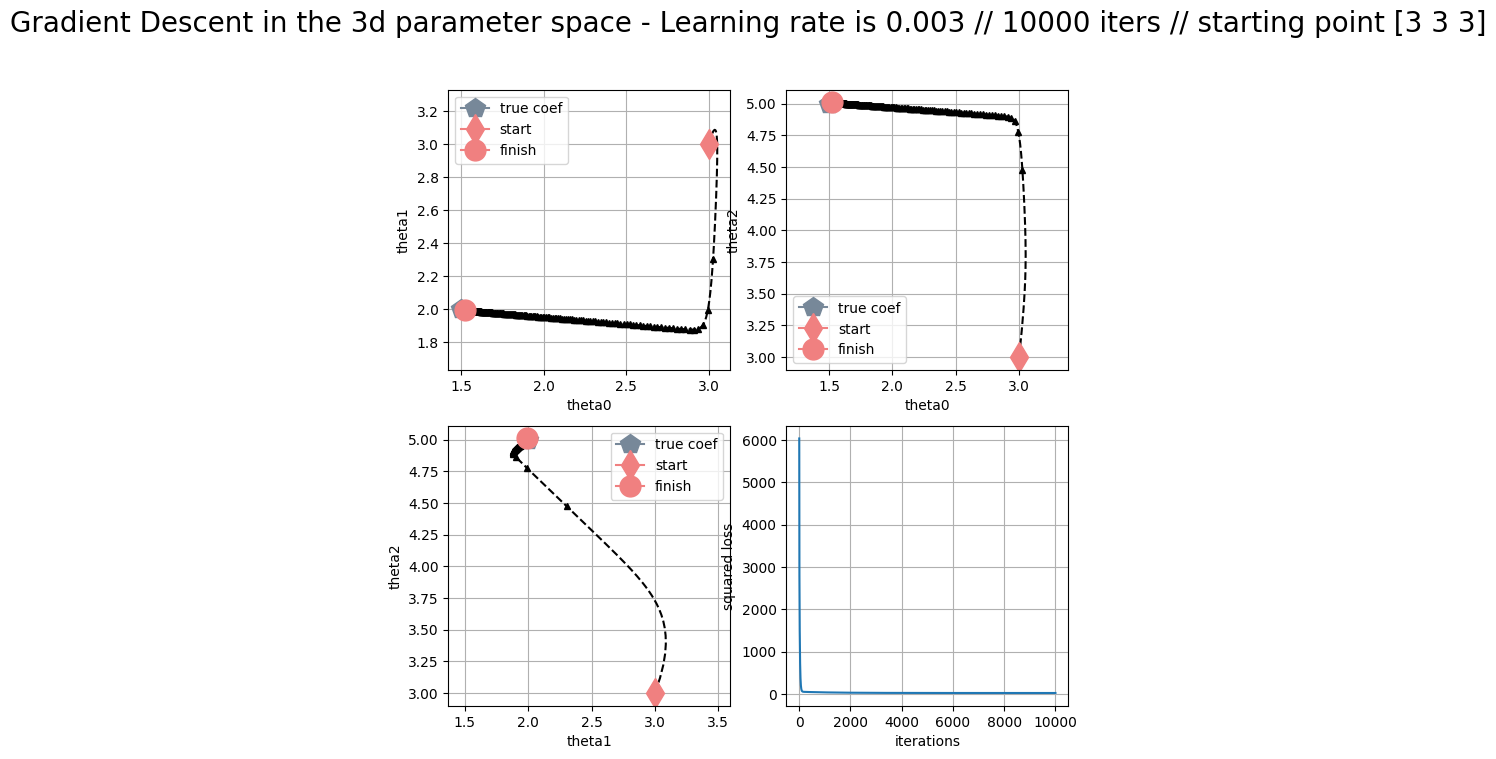

In [26]:
true_coef = [b, theta_1, theta_2]

def plot_ij(theta_path, i, j, ax):
    ax.plot(true_coef[i], true_coef[j],
            marker='p', markersize=15, label='true coef', 
            color='#778899')
    ax.plot(theta_path[:, i],theta_path[:, j],
            color='k', linestyle='--', marker='^', 
            markersize=5, markevery=50)
    ax.plot(theta_path[0, i], theta_path[0, j], marker='d', 
            markersize=15, label='start', color='#F08080')
    ax.plot(theta_path[-1, i], theta_path[-1, j], marker='o', 
            markersize=15, label='finish', color='#F08080')
    ax.set(
        xlabel='theta'+str(i),
        ylabel='theta'+str(j))
    ax.axis('equal')
    ax.grid(True)
    ax.legend(loc='best')
    

def plot_all(theta_path, loss_vec, learning_rate, num_iter, theta_initial, gdtype='Gradient Descent'):
    fig = plt.figure(figsize=(8, 8))
    title = '{gdtype} in the 3d parameter space - Learning rate is {lr} // {iters} iters // starting point {initial}'
    title = title.format(gdtype=gdtype, lr=learning_rate, 
                         iters=num_iter, initial=theta_initial)
    fig.suptitle(title, fontsize=20)
    ax = fig.add_subplot(2, 2, 1)
    plot_ij(theta_path, 0, 1, ax)
    ax = fig.add_subplot(2, 2, 2)
    plot_ij(theta_path, 0, 2, ax)
    ax = fig.add_subplot(2, 2, 3)
    plot_ij(theta_path, 1, 2, ax)
    ax = fig.add_subplot(2, 2, 4)
    ax.plot(loss_vec)
    ax.set(xlabel='iterations', ylabel='squared loss')
    ax.grid(True)
    

theta_path, loss_vec = gradient_descent(learning_rate, num_iter, theta_initial)
plot_all(theta_path, loss_vec, learning_rate, num_iter, theta_initial)

The above plot shows the path the algorithm takes towards the *real* parameter values. Each time the model evaluates the full dataset and calculates the error, then uses this error to update the parameters of the model. This is repeated for a set number of iterations.

In this method the average of the gradients of all datapoints is used.

## Stochastic Gradient Descent

Another way to do gradient descent is by using the individual gradients of datapoints to correct the parameter values. This will produce more noise in the path, but eventually will give a closer estimation.

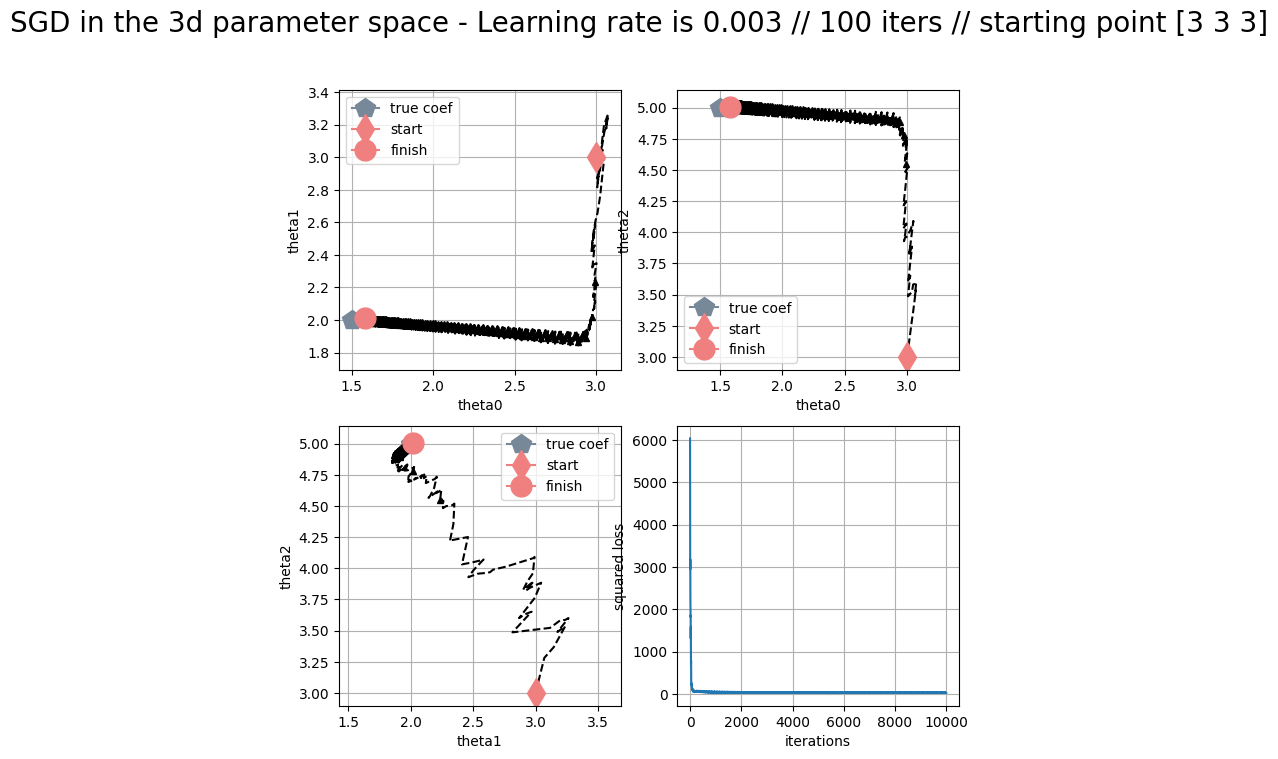

In [23]:
def stochastic_gradient_descent(learning_rate, num_iter, theta_initial):

    ## Initialization steps
    theta = theta_initial
    # below are different in STOCHASTIC gradient descent
    theta_path = np.zeros(((num_iter*num_obs)+1,3))
    theta_path[0,:] = theta_initial
    loss_vec = np.zeros(num_iter*num_obs)

    ## Main SGD loop
    count = 0
    for i in range(num_iter):
        for j in range(num_obs):
            count+=1
            y_pred = np.dot(theta.T,x_mat.T)
            loss_vec[count-1] = np.sum((y-y_pred)**2)
            grad_vec = (y[j]-y_pred[j])*(x_mat[j,:])
            theta = theta + learning_rate*grad_vec
            theta_path[count,:]=theta
    return theta_path, loss_vec

## Parameters to play with
learning_rate = 3e-3
num_iter = 100
theta_initial = np.array([3, 3, 3])


theta_path, loss_vec = stochastic_gradient_descent(learning_rate, 
                                                   num_iter, 
                                                   theta_initial)
plot_all(theta_path, loss_vec, learning_rate, 
         num_iter, theta_initial, 'SGD')

In this case the results are very similar when the learning rate is chosen well. But in many cases there might be more advantage to either method. Stochastic gradient descent can be de-biased more by randomising the dataset order each epoch. This way each gradient still contributes, but the order does not influence the result.

Batch gradient descent can be implemented more efficiently since bulk matrix calculations can be used. Since stochastic gradient descent requires successive updates for each datapoint, this is not possible as each next gradient requires the already updated parameters of the previous datapoint. A good compromise here is to use mini-batch GD, which splits the data into smaller batches that can be used to update the parameters. This way matrix calculations can be used, the flexibility and lower memory requirements of the stochastic method is retained and the convergence path is more stable.

The learning rate is extremely important, a too small value might never get close to the correct parameter values, while a too large value might jump around the correct value or even diverge. A good update to the static value is to use a dynamic value, usually one that starts out large and decreases with later iterations to a minimum value. This way the algorithm starts out taking large steps and takes smaller steps once it gets closer to the minimum of the cost function.